# Notebook 02 : Exploratory Data Analysis & Charts

**Goal:** Answer the business question visually. Each chart answers one specific question.

**Business question:** Which product categories and regions drive profitability?

**Output:** 5 chart PNGs saved to `../visuals/`

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/superstore_clean.csv', parse_dates=['Order Date', 'Ship Date'])
print(f'Loaded: {df.shape}')

sns.set_theme(style='whitegrid', palette='muted')
PLOT_COLOR = '#378ADD'

Loaded: (9994, 28)


## Chart 1 : Total sales by category

**Question:** Which category generates the most revenue?

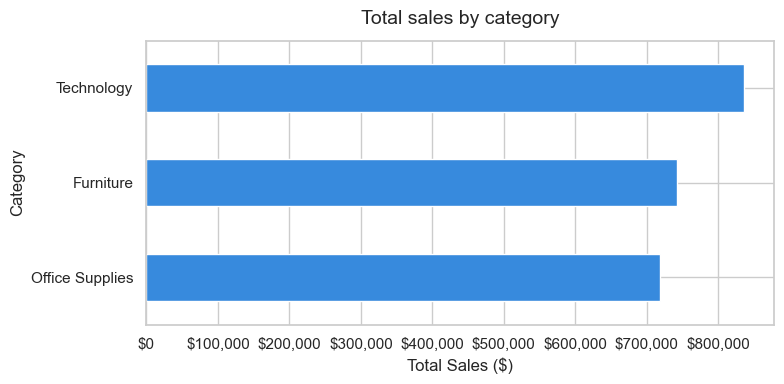

Chart 1 saved.


In [5]:
cat_sales = df.groupby('Category')['Sales'].sum().sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
cat_sales.plot(kind='barh', ax=ax, color=PLOT_COLOR)
ax.set_xlabel('Total Sales ($)')
ax.set_title('Total sales by category', fontsize=14, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../visuals/sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 1 saved.')

## Chart 2 : Profit by sub-category

**Question:** Which sub-categories are losing money? 

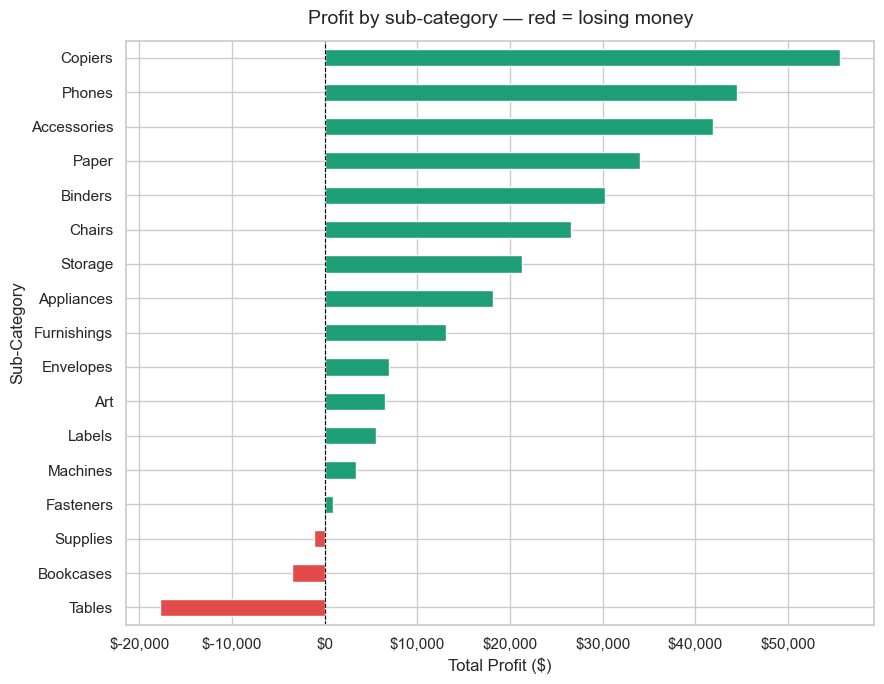

Chart 2 saved.


In [6]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#E24B4A' if v < 0 else '#1D9E75' for v in sub_profit.values]

fig, ax = plt.subplots(figsize=(9, 7))
sub_profit.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_xlabel('Total Profit ($)')
ax.set_title('Profit by sub-category — red = losing money', fontsize=14, pad=12)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../visuals/profit_by_subcategory.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 2 saved.')

## Chart 3 : Monthly sales trend

**Question:** Is the business growing? Are there seasonal patterns?

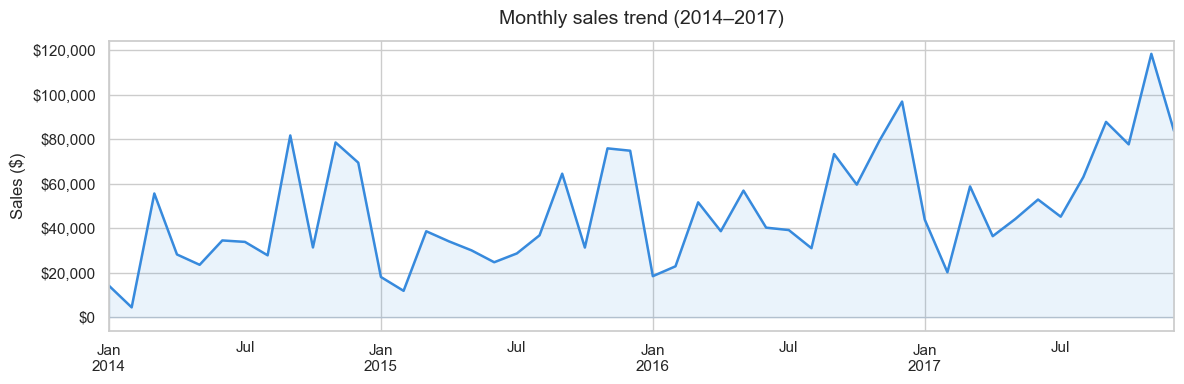

Chart 3 saved.


In [8]:
monthly = df.resample('ME', on='Order Date')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax, color=PLOT_COLOR, linewidth=1.8)
ax.fill_between(monthly.index, monthly.values, alpha=0.1, color=PLOT_COLOR)
ax.set_xlabel('')
ax.set_ylabel('Sales ($)')
ax.set_title('Monthly sales trend (2014–2017)', fontsize=14, pad=12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig('../visuals/monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 3 saved.')

## Chart 4 : Discount vs profit margin (key insight chart)

**Question:** Does discounting hurt profitability?


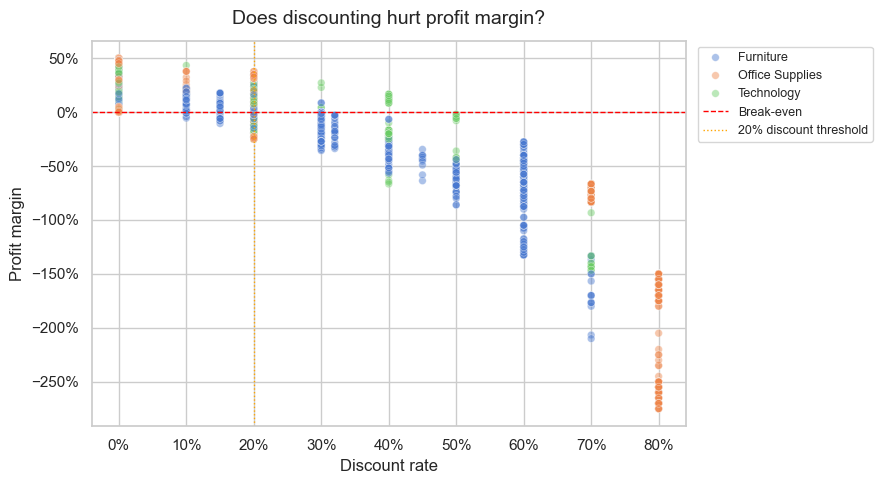

Chart 4 saved.


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.scatterplot(data=df, x='Discount', y='Profit Margin',
                hue='Category', alpha=0.45, s=30, ax=ax)
ax.axhline(0, color='red', linewidth=1, linestyle='--', label='Break-even')
ax.axvline(0.2, color='orange', linewidth=1, linestyle=':', label='20% discount threshold')
ax.set_xlabel('Discount rate')
ax.set_ylabel('Profit margin')
ax.set_title('Does discounting hurt profit margin?', fontsize=14, pad=12)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.xaxis.set_major_formatter(mticker.PercentFormatter(1.0))
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../visuals/discount_vs_profit.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 4 saved.')

## Chart 5 : Regional profit comparison

**Question:** Which region performs best?

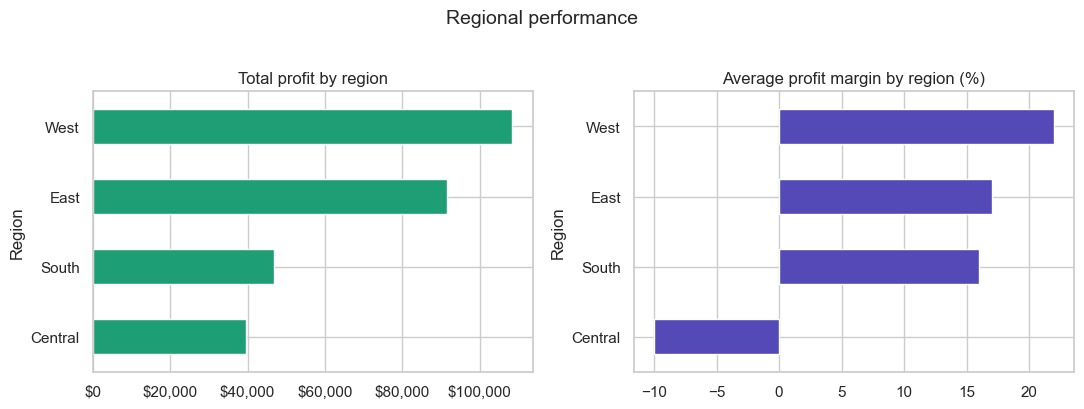

Chart 5 saved.

Regional summary:
         Total_Sales  Total_Profit  Avg_Margin
Region                                        
Central    501239.89      39706.36       -0.10
East       678781.24      91522.78        0.17
South      391721.90      46749.43        0.16
West       725457.82     108418.45        0.22


In [10]:
regional = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Margin=('Profit Margin', 'mean')
).round(2)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

regional['Total_Profit'].sort_values().plot(kind='barh', ax=axes[0], color='#1D9E75')
axes[0].set_title('Total profit by region')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

(regional['Avg_Margin'] * 100).sort_values().plot(kind='barh', ax=axes[1], color='#534AB7')
axes[1].set_title('Average profit margin by region (%)')

plt.suptitle('Regional performance', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../visuals/regional_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart 5 saved.')
print('\nRegional summary:')
print(regional)

## Summary : what the charts tell us

Update these findings with your actual numbers after running the notebook:

In [11]:
print('=== KEY FINDINGS ===')
print()

top_sub = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print('Top 3 most profitable sub-categories:')
print(top_sub.head(3).to_string())
print()

loss_sub = top_sub[top_sub < 0]
print(f'Sub-categories losing money: {list(loss_sub.index)}')
print()

high_discount = df[df['Discount'] >= 0.2]
low_discount = df[df['Discount'] < 0.2]
print(f'Avg margin with discount >= 20%: {high_discount["Profit Margin"].mean():.1%}')
print(f'Avg margin with discount < 20%:  {low_discount["Profit Margin"].mean():.1%}')

=== KEY FINDINGS ===

Top 3 most profitable sub-categories:
Sub-Category
Copiers        55617.8249
Phones         44515.7306
Accessories    41936.6357

Sub-categories losing money: ['Supplies', 'Bookcases', 'Tables']

Avg margin with discount >= 20%: -8.8%
Avg margin with discount < 20%:  33.3%
